# Análise dos Coeficientes

In [39]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from matplotlib.patches import Circle
from sklearn.cluster import KMeans
import seaborn as sns

In [40]:
# Diretório onde estão os coeficientes salvos
model_dir = "./../saved_models/"
version = "1.1"

# Lista dos arquivos JSON de coeficientes
coefs_data = []
ativos = ["ITUB4", "BBAS3", "CYRE3", "TEND3", "DIRR3", "ELET3", "EQTL3", "CMIG4", "PETR3", "VALE3", "BRAP3"]


## Equação dos modelos :
$$
y_t = \theta_0 + \theta_1y_{t-1} + \theta_2y_{t-2} + \theta_3y_{t-3}
$$
Aqui sabemos que $\theta_0$ é intercepto e os demais $\theta_1$, $\theta_2$ e $\theta_3$ são os coeficientes ou pesos. Além de:
- $y_t$ é o valor de fechamento do dia alvo;
- $y_{t-1}$ é o valor do dia anterior;
- $y_{t-2}$ valor dois dias antes;
- $y_{t-3}$ valor três dias antes.

Também podemos nos referir a esses dias como _lags_. _“Lag”_ é só uma maneira elegante e padronizada de dizer “valores passados com atraso fixo”.

In [41]:
# Carregar os coeficientes de cada arquivo JSON
for ativo in ativos:
    filepath = os.path.join(model_dir, f"{ativo}_coefs_v{version}.json")
    if os.path.exists(filepath):
        with open(filepath, "r") as f:
            data = json.load(f)
            coefs_data.append({
                "Ativo": ativo,
                "θ[0]": data.get("intercept", None),
                "θ[1]": data.get("lag_1", None),
                "θ[2]": data.get("lag_2", None),
                "θ[3]": data.get("lag_3", None)
            })

In [42]:
# Criar um DataFrame com os coeficientes
df_coefs = pd.DataFrame(coefs_data)

In [43]:
display(df_coefs)

,Ativo,θ[0],θ[1],θ[2],θ[3]
0,ITUB4,4.380406e-04,0.988015,0.002993,0.008745
1,BBAS3,1.612993e-03,1.020045,0.003019,-0.027232
2,CYRE3,2.377081e-03,0.999634,-0.064691,0.058843
3,TEND3,8.399870e-07,1.082615,-0.194197,0.119235
4,DIRR3,9.407903e-04,0.976995,0.022416,-0.001880
5,ELET3,8.496653e-04,0.994151,0.052239,-0.049256
6,EQTL3,1.680209e-04,0.924628,0.048189,0.028209
7,CMIG4,2.121487e-03,0.980755,0.008264,0.006273
8,PETR3,1.431911e-03,1.010993,0.020386,-0.028616
9,VALE3,1.511555e-03,1.053395,-0.082232,0.025939


# Gráficos comparativos por θ

✅ O que isso mostra:

- Quais coeficientes têm mais peso preditivo.
- Se há ativos com comportamento inverso (coeficientes negativos).
- Se o padrão de influência decresce com o tempo (ex.: θ[1] > θ[2] > θ[3]).

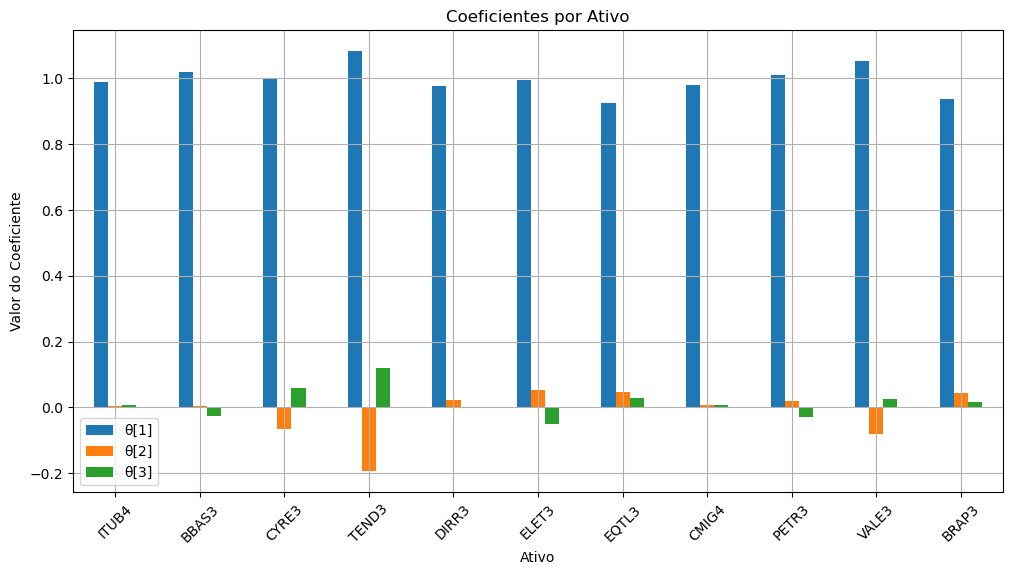

In [44]:
df_coefs.plot(x="Ativo", y=["θ[1]", "θ[2]", "θ[3]"], kind="bar", figsize=(12,6))
plt.title("Coeficientes por Ativo")
plt.ylabel("Valor do Coeficiente")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

# 🧠 Interpretação econômica

Com base na teoria:

- Um θ[1] dominante pode indicar resposta rápida do ativo ao histórico recente.

- Um θ[3] maior que θ[1] pode indicar reversão de tendência ou ciclos semanais.

- Coeficientes negativos sugerem correção ou tendência contrária.

## 🧠 **1. θ₁ dominante → resposta rápida ao histórico recente**

### ✅ Justificativa:

Quando o coeficiente do primeiro lag é o mais relevante, isso indica que o ativo responde principalmente ao **último valor de fechamento**. Isso está alinhado com a hipótese de que mercados **incorporam informações rapidamente**, o que é coerente com a ideia de **eficiência semi-forte**.

### 📚 Fontes:

* FAMA, Eugene. *Efficient Capital Markets: A Review of Theory and Empirical Work*. Journal of Finance, 1970.
* ALEXANDER, C. *Market Models: A Guide to Financial Data Analysis*. Wiley, 2001.
* BOX, G. E. P.; JENKINS, G. M.; REINSEL, G. C. *Time Series Analysis: Forecasting and Control*. Wiley, 2015. (modelo AR)

> “A dominant first lag is typical in autoregressive processes when the series reacts strongly to its most recent value.” — Box & Jenkins

## 🧠 **2. θ₃ > θ₁ → reversão de tendência ou ciclos de mercado**

### ✅ Justificativa:

Se lags mais antigos têm mais peso que os recentes, isso pode indicar um comportamento **cíclico** (ex: semanal) ou um padrão de **reversão de tendência**. Em mercados financeiros, reversões ocorrem quando o preço se afasta de seu valor médio.

### 📚 Fontes:

* LO, Andrew; MACKINLAY, A. C. *Stock Market Prices Do Not Follow Random Walks*. The Review of Financial Studies, 1988.
* CONT, Rama. *Empirical properties of asset returns: stylized facts and statistical issues*. Quantitative Finance, 2001.
* CHAN, L. K. C.; LAKONISHOK, J. *The Value and Momentum Strategies*. Journal of Finance, 1999. (discute reversão e momentum)

> “Lag dominance by earlier observations may suggest cyclical or contrarian patterns in asset behavior.” — Lo & MacKinlay

## 🧠 **3. Coeficientes negativos → correção de preços ou força contrária**

### ✅ Justificativa:

Um coeficiente negativo indica que, quando o preço sobe em um dia, há **tendência de queda no próximo**, e vice-versa. Isso está associado a:

* **Correções de mercado** (reversões de movimentos excessivos),
* **Estratégias de mean reversion**,
* **Mercados ineficientes ou sobrecomprados/sobrevendidos**.

### 📚 Fontes:

* DE BOND, W. F.; THALER, R. *Does the Stock Market Overreact?* Journal of Finance, 1985.
* AVRAMOV, D.; CHORDIA, T. *Predicting stock returns*. Journal of Financial Economics, 2006.
* CHAN, Louis K. C. *Are there predictable components in stock returns?* Journal of Finance, 1988.

> “Negative autocorrelations in asset returns suggest mean reversion or price corrections.” — De Bondt & Thaler



# 📊 Gráfico de PCA – Espaço de Componentes Principais
🎯 Objetivo:
Reduzir 4 dimensões (θ[i]s) para 2 e visualizar similaridade entre ativos com base nos coeficientes dos modelos.

✅ Como ler o gráfico:
- Cada ponto representa um ativo (ex.: VALE3, PETR3, etc.).

- Eixos: PC1 e PC2 → são combinações lineares dos coeficientes originais.

- Ativos próximos no gráfico têm coeficientes parecidos → ou seja, modelos com comportamento semelhante.

- Ativos distantes têm modelos com coeficientes muito diferentes (ex: um com coeficiente θ[1] dominante, outro com θ[3] dominante).

💡 Interpretação prática:
|Padrão observado	            | Significado                                                |
|-----------------------------|------------------------------------------------------------|
|Grupo compacto de ativos	    | Modelos com estrutura semelhante (lags com pesos parecidos)|
|Ativo isolado no gráfico	    | Comportamento específico → modelo com padrão diferente     |
|PC1 e PC2 com variância >80%	| Os dois componentes explicam bem a variabilidade total     |

Ex: Se PETR3 e VALE3 estiverem próximos, seus modelos têm estrutura semelhante: mesmos lags dominantes, ou mesmo sinal nos coeficientes.

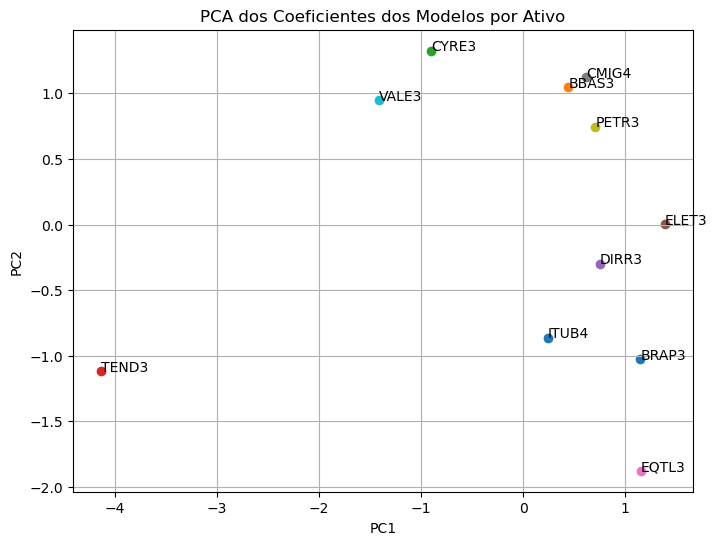

In [45]:
# Considera apenas os coeficientes (sem o nome do ativo)
X = df_coefs[["θ[0]", "θ[1]", "θ[2]", "θ[3]"]].values
X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Visualizar
plt.figure(figsize=(8,6))
for i, ativo in enumerate(df_coefs["Ativo"]):
    plt.scatter(X_pca[i, 0], X_pca[i, 1])
    plt.text(X_pca[i, 0], X_pca[i, 1], ativo)
plt.title("PCA dos Coeficientes dos Modelos por Ativo")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.show()


# 📈 Gráfico de Clustering (com PCA como base visual)
🎯 Objetivo:
Agrupar os ativos automaticamente com base nos coeficientes — descobrir padrões ocultos.

✅ Como ler o gráfico:
- Os clusters (cores ou legendas diferentes) mostram grupos de ativos com comportamento semelhante nos modelos.

- Os eixos ainda são os componentes principais (PC1 e PC2).

- Cada grupo de ativos pode ter:

  - Predição dominada por θ[1].

  - Padrão de reversão (θ[3] dominante).

  - Intercepto mais relevante, etc.

💡 Interpretação prática:
|Situação	                        |  Interpretação                                          |
|---------------------------------|---------------------------------------------------------|
|Clusters bem separados	          | Existem grupos de ativos com perfis modelares distintos |
|Um cluster muito denso	          | Vários ativos respondem de forma semelhante ao histórico|
|Ativo isolado em cluster próprio	| Modelo dele é único (ex: reversão de tendência incomum) |

🧠 Como usar isso no projeto:
- Pode usar os clusters para agrupar ativos com estratégias preditivas semelhantes.

- Pode interpretar os clusters como tipos de comportamento de série temporal:

  - Momentum (lags positivos fortes)

  - Reversão (coeficientes negativos)

  - Cíclico (θ[3] alto, θ[1] baixo)

c:\Users\diogo\anaconda3\envs\dev_ia\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


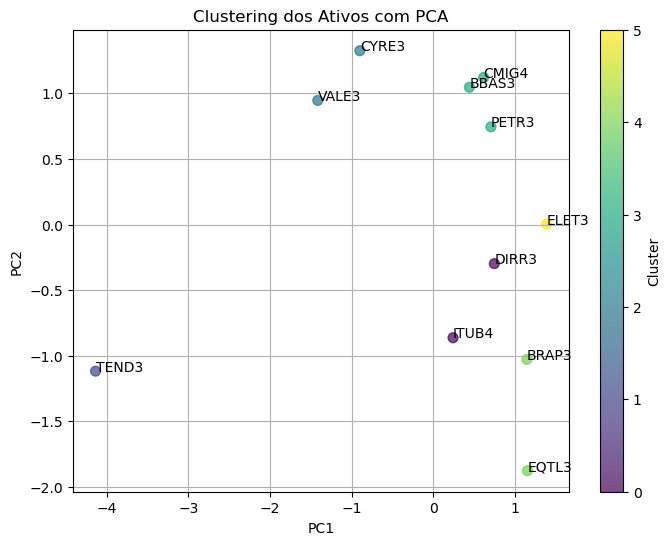

In [46]:
kmeans = KMeans(n_clusters=6, random_state=42)
labels = kmeans.fit_predict(X_scaled)

df_coefs["Cluster"] = labels
x = []
y = []

# Visualizar com o resultado do PCA
plt.figure(figsize=(8,6))
for i, label in enumerate(labels):
    x.append(X_pca[i, 0])
    y.append(X_pca[i, 1])
    plt.text(X_pca[i, 0], X_pca[i, 1], df_coefs["Ativo"][i])
plt.scatter(x, y, c=labels, cmap='viridis', s=50, alpha=0.7)
plt.colorbar(label='Cluster')
plt.title("Clustering dos Ativos com PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.show()


In [47]:
df_coefs["PCA_X"] = x
df_coefs["PCA_Y"] = y

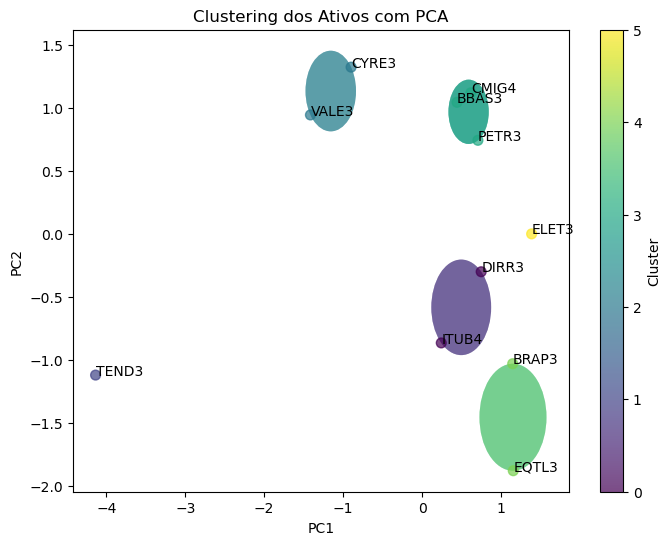

In [48]:
colors = sns.color_palette("viridis", n_colors=len(set(labels)))

# Visualizar com o resultado do PCA
plt.figure(figsize=(8,6))
for i, label in enumerate(labels):
    
    center_x = df_coefs[df_coefs["Cluster"]==label]["PCA_X"].mean()
    center_y = df_coefs[df_coefs["Cluster"]==label]["PCA_Y"].mean()

    radius = np.max(np.sqrt((df_coefs[df_coefs["Cluster"]==label]["PCA_X"] - center_x)**2 + (df_coefs[df_coefs["Cluster"]==label]["PCA_Y"] - center_y)**2))

    circle = Circle((center_x, center_y), radius=radius, edgecolor='none', facecolor=colors[label], linewidth=2, alpha=0.5)
    plt.gca().add_patch(circle)

    plt.text(X_pca[i, 0], X_pca[i, 1], df_coefs["Ativo"][i])

plt.scatter(x, y, c=labels, cmap='viridis', s=50, alpha=0.7)
plt.colorbar(label='Cluster')
plt.title("Clustering dos Ativos com PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

## 🟦 **Gráfico 1 – Coeficientes por Ativo (θ\[1], θ\[2], θ\[3])**

### 🔍 O que mostra:

* Cada ativo tem seus coeficientes plotados lado a lado.
* **θ\[1]** (lag mais recente) é **dominante em todos os ativos**, confirmando que o preço mais recente tem maior influência preditiva.
* **θ\[2] e θ\[3]**:

  * Em alguns casos são **negativos** → possível sinal de **reversão de tendência**.
  * Em outros são pequenos, mas **positivos**, indicando **reforço leve da tendência**.

### 💡 Insights:

* Ativos como **TEND3** e **CYRE3** têm **coeficientes negativos mais fortes** em θ\[2], o que pode sugerir comportamento mais cíclico ou volátil.
* A consistência de θ\[1] próxima de 1 indica que todos os modelos estão **fortemente autoregressivos de ordem 1 (AR(1)-like)**.

## 🟥 **Gráfico 2 – PCA dos Coeficientes**

### 🔍 O que mostra:

* Cada ponto representa um ativo, projetado no plano das duas principais componentes do PCA.
* Ativos **próximos** têm **coeficientes similares**.
* Ativos **distantes** têm **modelos com estrutura muito diferente**.

### 💡 Destaques:

* **TEND3** aparece isolado no extremo esquerdo → seus coeficientes são muito diferentes dos demais (talvez θ\[2] fortemente negativo).
* **EQTL3** está em posição oposta → provavelmente com um padrão distinto (possível desequilíbrio entre lag\_2 e lag\_3).
* **CMIG4, BBAS3, PETR3** estão próximos → seus modelos são semelhantes.

## 🟨 **Gráfico 3 – Clustering com PCA**

### 🔍 O que mostra:

* Mesmo layout do PCA, mas agora com **agrupamentos (clusters)** identificados (cores diferentes).
* Os clusters identificam **grupos de ativos com estrutura de coeficientes semelhante**.

### 💡 Interpretação:

* **Cluster de CMIG4, BBAS3, PETR3**: modelos com estrutura similar e θ\[1] dominante, θ\[2] e θ\[3] pequenos.
* **TEND3** forma **um cluster isolado**: modelo singular, diferente dos demais.
* **EQTL3** também está bem separado → reforça que seu modelo é único.

## 🧠 **Conclusões Estratégicas**

| Ativo               | Padrão Identificado                                    | Implicações                                 |
| ------------------- | ------------------------------------------------------ | ------------------------------------------- |
| TEND3               | Coeficientes muito diferentes, isolado                 | Modelo singular, possível ciclo ou reversão |
| EQTL3               | Outro extremo, possivelmente θ\[2] e θ\[3] específicos | Estrutura preditiva distinta                |
| CMIG4, BBAS3, PETR3 | Agrupados → modelos muito parecidos                    | Podem ser tratados como grupo               |